In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [0]:
# --------------------------------------------------
# 1. Text data(Sports, Food, Data Engineering)
# --------------------------------------------------

texts = [
    "Chocolate cake",
    "Kafka streaming",
    "Football match",
    "Snowflake warehouse",
    "Mango smoothie",
    "Apache Spark",
    "Tennis player",
    "Chicken biryani",
    "Databricks cluster",
    "World Cup",
    "Vegetable soup",
    "Airflow pipeline",
    "Basketball game",
    "Cheese pizza",
    "Delta Lake",
    "Olympic athlete",
    "Grilled chicken",
    "Cricket tournament"
]

df = pd.DataFrame({
    "TEXT": texts
})

display(df)

TEXT
Chocolate cake
Kafka streaming
Football match
Snowflake warehouse
Mango smoothie
Apache Spark
Tennis player
Chicken biryani
Databricks cluster
World Cup


In [0]:
from pyspark.sql.functions import *

In [0]:
embed_spark_df = spark.createDataFrame(df)

embed_spark_df = embed_spark_df.withColumn(
    "EMBEDDING",
    expr("""
        ai_query(
            'databricks-gte-large-en',
            TEXT,
            returnType => 'array<float>'
        )
    """)
)

# Bring result to Pandas
embed_df = embed_spark_df.toPandas()

In [0]:
embed_df

,TEXT,EMBEDDING
0,Chocolate cake,"[-0.126708984375, -0.5751953125, -0.7016601562..."
1,Kafka streaming,"[-0.25537109375, 0.219482421875, 0.26489257812..."
2,Football match,"[-0.496826171875, 0.92626953125, -1.09765625, ..."
3,Snowflake warehouse,"[-0.888671875, -0.0104522705078125, 0.08599853..."
4,Mango smoothie,"[0.07501220703125, -0.08319091796875, -0.49902..."
5,Apache Spark,"[0.80908203125, 0.322021484375, -0.15710449218..."
6,Tennis player,"[-0.478759765625, -0.69140625, -1.666015625, -..."
7,Chicken biryani,"[-1.0390625, -0.09381103515625, 0.353271484375..."
8,Databricks cluster,"[0.414306640625, 0.15869140625, 0.6611328125, ..."
9,World Cup,"[-0.6142578125, 0.67041015625, -1.6826171875, ..."


In [0]:
embeddings = np.array(
    embed_df["EMBEDDING"].tolist()
)

print("Embeddings shape:", embeddings.shape)

Embeddings shape: (18, 1024)


In [0]:
scaler = StandardScaler()

embeddings_normalized = scaler.fit_transform(
    embeddings
)

In [0]:
pca = PCA(
    n_components=2,
    random_state=42
)

embeddings_pca = pca.fit_transform(
    embeddings_normalized
)

print("PCA shape:", embeddings_pca.shape)

PCA shape: (18, 2)


In [0]:
inertias = []

k_values = range(1, 10)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(embeddings_pca)

    inertias.append(kmeans.inertia_)

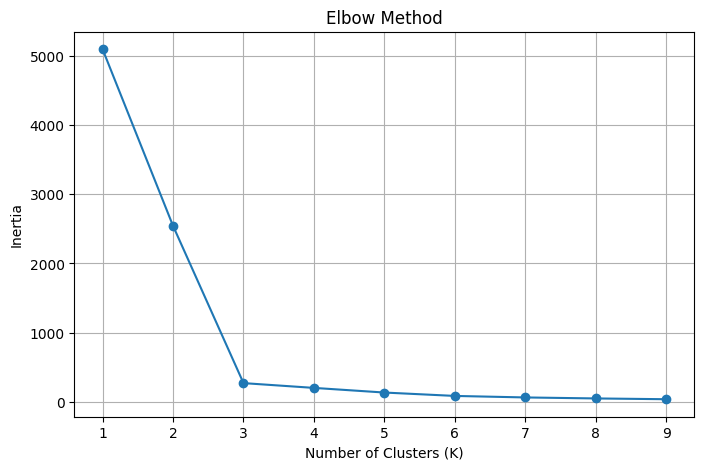

In [0]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [0]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    embeddings_pca
)

In [0]:
result = embed_df[["TEXT"]].copy()

result["PC1"] = embeddings_pca[:, 0]
result["PC2"] = embeddings_pca[:, 1]
result["CLUSTER"] = clusters

display(result.sort_values("CLUSTER"))

TEXT,PC1,PC2,CLUSTER
Cricket tournament,16.92332830963917,-0.7695804601188432,0
Olympic athlete,13.610610648993326,7.274984899520975,0
Football match,18.98276567488573,0.4955244929064502,0
Basketball game,15.436037740892433,2.3817709879431277,0
Tennis player,13.885031125704453,4.284638851591486,0
World Cup,21.349838423403273,0.14188629199574002,0
Cheese pizza,-5.270348444987876,-13.002146247085305,1
Vegetable soup,-6.905911720142375,-12.147454484144005,1
Chocolate cake,-5.4926800200175485,-12.186918689513563,1
Chicken biryani,-7.537629519643292,-18.768479090700136,1
